<a href="https://colab.research.google.com/github/MoeinSheikhottayefe/Networkx/blob/main/A_try_of_nxviz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install nxviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 14.0 MB/s eta 0:00:00


The following code illustate the usage of the package nxviz. and also shows that the meta data will be lost after converitng the matrix .A graph has two fundamentally different types of information: structure and attributes — and not all representations preserve both.

=== Original Node Metadata ===
Node 0: {'name': 'Alice', 'category': 'Scientist'}
Node 1: {'name': 'Bob', 'category': 'Engineer'}
Node 2: {'name': 'Charlie', 'category': 'Artist'}
Node 3: {'name': 'David', 'category': 'Scientist'}
Node 4: {'name': 'Emma', 'category': 'Doctor'}


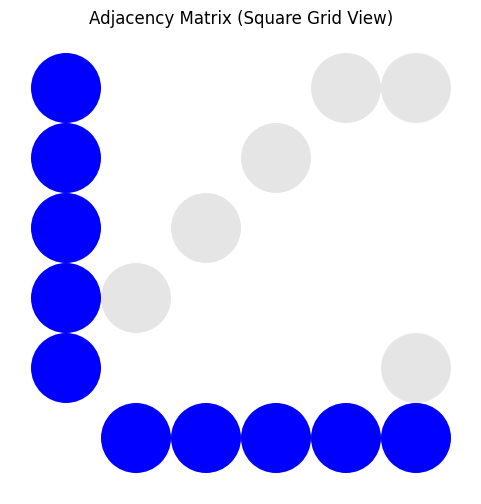


=== NumPy Adjacency Matrix ===
[[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]]

=== Metadata After Reconstruction ===
Node 0: No metadata found!
Node 1: No metadata found!
Node 2: No metadata found!
Node 3: No metadata found!
Node 4: No metadata found!

✓ Verification successful:
Node metadata is lost after converting the graph to a NumPy adjacency matrix.


In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from nxviz import matrix

# ==========================================
# 1. Create a directed social network
# ==========================================
T = nx.DiGraph()

# Add nodes with metadata
T.add_node(0, name='Alice', category='Scientist')
T.add_node(1, name='Bob', category='Engineer')
T.add_node(2, name='Charlie', category='Artist')
T.add_node(3, name='David', category='Scientist')
T.add_node(4, name='Emma', category='Doctor')

# Add directed edges
T.add_edges_from([
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 0),
    (4, 4)   # Self-loop
])

# ==========================================
# 2. Show the original metadata
# ==========================================
print("=== Original Node Metadata ===")

for n, d in T.nodes(data=True):
    print(f"Node {n}: {d}")

# ==========================================
# 3. Visualize the adjacency matrix
# ==========================================
plt.figure(figsize=(6, 6))

matrix(T)

plt.title("Adjacency Matrix (Square Grid View)")
plt.show()

# ==========================================
# 4. Convert the graph to a NumPy array
# ==========================================
A = nx.to_numpy_array(T)

print("\n=== NumPy Adjacency Matrix ===")
print(A)

# ==========================================
# 5. Convert back to a NetworkX graph
# ==========================================
T_conv = nx.from_numpy_array(
    A,
    create_using=nx.DiGraph()
)

# ==========================================
# 6. Check whether metadata is preserved
# ==========================================
print("\n=== Metadata After Reconstruction ===")

for n, d in T_conv.nodes(data=True):

    if not d:
        print(f"Node {n}: No metadata found!")
    else:
        print(f"Node {n}: {d}")

# ==========================================
# 7. Automatic verification
# ==========================================
for n, d in T_conv.nodes(data=True):
    assert 'category' not in d

print(
    "\n✓ Verification successful:"
    "\nNode metadata is lost after converting the graph to a NumPy adjacency matrix."
)

the cicos polt of the matrix would be

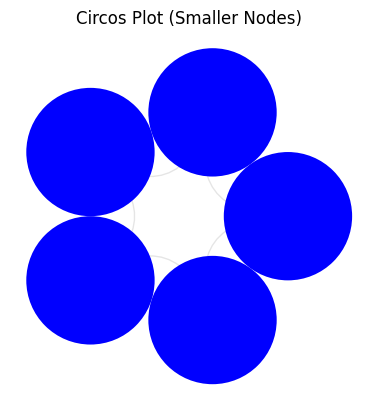

In [15]:
import matplotlib.pyplot as plt
from nxviz import circos

# Circos plot with smaller nodes
c = circos(T)  # یا در بعضی نسخه‌ها: node_radius=0.02

plt.title("Circos Plot (Smaller Nodes)")
plt.show()

nxviz tries his best but it is not what I want so I switch back to the original networkx

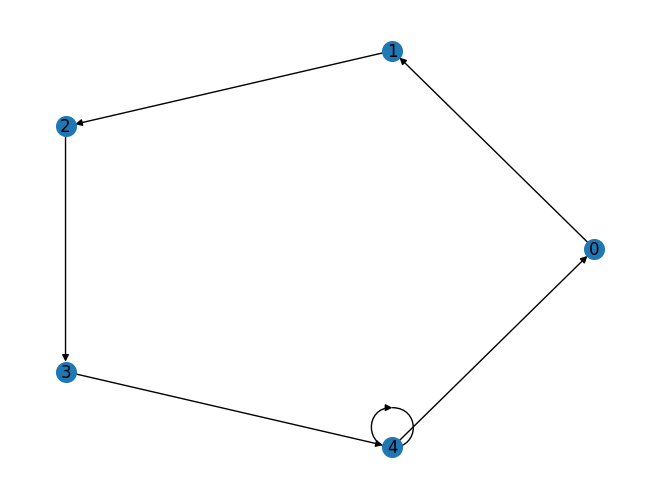

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

pos = nx.circular_layout(T)

nx.draw(
    T,
    pos,
    with_labels=True,
    node_size=200,
    arrows=True
)

plt.show()

to use the arc visialization it seems that we just afew options such as nxviz which are not so good....

In [18]:
from nxviz import arc

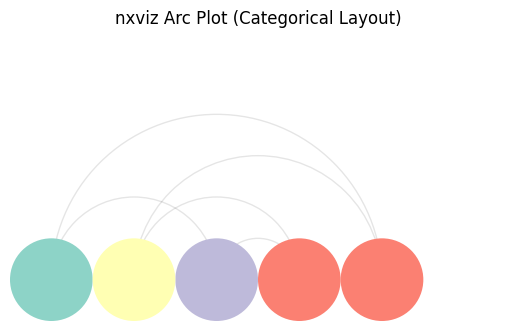

In [20]:
# ==========================================
# 1. nxviz Arc plot (circular arc visualization)
# ==========================================
a = arc(T, sort_by='category', node_color_by='category')

plt.title("nxviz Arc Plot (Categorical Layout)")
plt.show()


